In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [3]:
# Read the data into a Pandas DataFrame

input_gen = "/Users/mac/Desktop/ RED/Data Final Project/AGGREGATED_GENERATION_PER_TYPE_GENERATION_202312312300-202412312300.csv"  # Load the Excel file
input_price = "/Users/mac/Desktop/ RED/Data Final Project/GUI_ENERGY_PRICES_202412222300-202412232300.csv"  # Load the Excel file
input_load = "/Users/mac/Desktop/ RED/Data Final Project/GUI_TOTAL_LOAD_DAYAHEAD_202312312300-202412312300.csv"  # Load the Excel file




In [5]:
df_gen= pd.read_csv(input_gen)  
df_price= pd.read_csv(input_price)
df_load= pd.read_csv(input_load)

In [7]:
#df_load.head(50)
#df_price.head(50)

In [9]:

df_gen.head(50)

,MTU (CET/CEST),Area,Production Type,Generation (MW)
0,01/01/2024 00:00:00 - 01/01/2024 00:15:00,BZN|ES,Biomass,244.00
1,01/01/2024 00:00:00 - 01/01/2024 00:15:00,BZN|ES,Fossil Brown coal/Lignite,0.00
2,01/01/2024 00:00:00 - 01/01/2024 00:15:00,BZN|ES,Fossil Coal-derived gas,0.00
3,01/01/2024 00:00:00 - 01/01/2024 00:15:00,BZN|ES,Fossil Gas,4552.00
4,01/01/2024 00:00:00 - 01/01/2024 00:15:00,BZN|ES,Fossil Hard coal,280.00
5,01/01/2024 00:00:00 - 01/01/2024 00:15:00,BZN|ES,Fossil Oil,24.00
6,01/01/2024 00:00:00 - 01/01/2024 00:15:00,BZN|ES,Fossil Oil shale,0.00
7,01/01/2024 00:00:00 - 01/01/2024 00:15:00,BZN|ES,Fossil Peat,0.00
8,01/01/2024 00:00:00 - 01/01/2024 00:15:00,BZN|ES,Geothermal,0.00
9,01/01/2024 00:00:00 - 01/01/2024 00:15:00,BZN|ES,Hydro Pumped Storage,1548.00


In [11]:
# Split the 'MTU (CET/CEST)' column into 'Start Time' and 'End Time'
df_gen[["Start TimeFrame", "End TimeFrame"]] = df_gen["MTU (CET/CEST)"].str.split(" - ", expand=True)

# Remove the 'MTU (CET/CEST)' column
df_gen = df_gen.drop(columns=["MTU (CET/CEST)"])

In [12]:
df_gen

,Area,Production Type,Generation (MW),Start TimeFrame,End TimeFrame
0,BZN|ES,Biomass,244.00,01/01/2024 00:00:00,01/01/2024 00:15:00
1,BZN|ES,Fossil Brown coal/Lignite,0.00,01/01/2024 00:00:00,01/01/2024 00:15:00
2,BZN|ES,Fossil Coal-derived gas,0.00,01/01/2024 00:00:00,01/01/2024 00:15:00
3,BZN|ES,Fossil Gas,4552.00,01/01/2024 00:00:00,01/01/2024 00:15:00
4,BZN|ES,Fossil Hard coal,280.00,01/01/2024 00:00:00,01/01/2024 00:15:00
...,...,...,...,...,...
737851,BZN|ES,Waste,-,31/12/2024 23:45:00,01/01/2025 00:00:00
737852,BZN|ES,Wind Offshore,-,31/12/2024 23:45:00,01/01/2025 00:00:00
737853,BZN|ES,Wind Onshore,-,31/12/2024 23:45:00,01/01/2025 00:00:00
737854,BZN|ES,Other,-,31/12/2024 23:45:00,01/01/2025 00:00:00


In [18]:
# Convert 'Start TimeFrame' and 'End TimeFrame' to datetime
df_gen["Start TimeFrame"] = pd.to_datetime(df_gen["Start TimeFrame"], format="%d/%m/%Y %H:%M:%S")
df_gen["End TimeFrame"] = pd.to_datetime(df_gen["End TimeFrame"], format="%d/%m/%Y %H:%M:%S")


In [20]:
# Convert 'Generation (MW)' column to numeric, forcing errors to NaN if conversion fails
df_gen['Generation (MW)'] = pd.to_numeric(df_gen['Generation (MW)'], errors='coerce')

# Convert 'Start TimeFrame' to the nearest hour (for resampling)
df_gen['DateTime'] = df_gen['Start TimeFrame'].dt.floor('h')

# Group by the hourly intervals and production type, then sum the generation values
df_gen_hourly = df_gen.groupby(['DateTime', 'Production Type'], as_index=False)['Generation (MW)'].sum()

# Display the result
df_gen_hourly.head(48)

,DateTime,Production Type,Generation (MW)
0,2024-01-01 00:00:00,Biomass,988.0
1,2024-01-01 00:00:00,Energy storage,0.0
2,2024-01-01 00:00:00,Fossil Brown coal/Lignite,0.0
3,2024-01-01 00:00:00,Fossil Coal-derived gas,0.0
4,2024-01-01 00:00:00,Fossil Gas,17748.0
5,2024-01-01 00:00:00,Fossil Hard coal,1120.0
6,2024-01-01 00:00:00,Fossil Oil,84.0
7,2024-01-01 00:00:00,Fossil Oil shale,0.0
8,2024-01-01 00:00:00,Fossil Peat,0.0
9,2024-01-01 00:00:00,Geothermal,0.0


In [22]:
# Step 0: Define renewable production types
renewable_types = ['Biomass', 'Hydro Pumped Storage', 'Hydro Run-of-river and poundage', 'Hydro Water Reservoir', 'Other renewable', 'Solar', 'Wind Offshore', 'Wind Onshore']

# Step 1: Group the data by hour and production type, summing the generation
df_gen_hourly = df_gen.groupby(['DateTime', 'Production Type'], as_index=False)['Generation (MW)'].sum()

# Step 2: Create the 'Is Renewable' column in the grouped dataframe
df_gen_hourly['Is Renewable'] = df_gen_hourly['Production Type'].isin(renewable_types)

# Step 3: Calculate total generation per hour
df_gen_hourly['Total Generation (MW)'] = df_gen_hourly.groupby('DateTime')['Generation (MW)'].transform('sum')

# Step 4: Calculate renewable generation per hour
df_gen_hourly['Renewable Generation (MW)'] = df_gen_hourly.apply(
    lambda row: row['Generation (MW)'] if row['Is Renewable'] else 0, axis=1
)

# Step 5: Calculate the share of renewable generation
df_gen_hourly['Hourly Renewable Share (%)'] = (df_gen_hourly['Renewable Generation (MW)'] / df_gen_hourly['Total Generation (MW)']) * 100

# Display the result
df_gen_hourly[['DateTime', 'Production Type', 'Generation (MW)', 'Hourly Renewable Share (%)']].head(48)


,DateTime,Production Type,Generation (MW),Hourly Renewable Share (%)
0,2024-01-01 00:00:00,Biomass,988.0,1.103516
1,2024-01-01 00:00:00,Energy storage,0.0,0.000000
2,2024-01-01 00:00:00,Fossil Brown coal/Lignite,0.0,0.000000
3,2024-01-01 00:00:00,Fossil Coal-derived gas,0.0,0.000000
4,2024-01-01 00:00:00,Fossil Gas,17748.0,0.000000
5,2024-01-01 00:00:00,Fossil Hard coal,1120.0,0.000000
6,2024-01-01 00:00:00,Fossil Oil,84.0,0.000000
7,2024-01-01 00:00:00,Fossil Oil shale,0.0,0.000000
8,2024-01-01 00:00:00,Fossil Peat,0.0,0.000000
9,2024-01-01 00:00:00,Geothermal,0.0,0.000000


In [24]:
# Calculate total renewable and total generation across all hours
total_renewable_generation = df_gen_hourly['Renewable Generation (MW)'].sum()
total_generation = df_gen_hourly['Total Generation (MW)'].sum()

# Calculate the overall share of renewable generation
overall_renewable_share = (total_renewable_generation / total_generation) * 100

# Display the result
print(f"Overall Renewable Generation Share: {overall_renewable_share:.2f}%")

Overall Renewable Generation Share: 2.87%


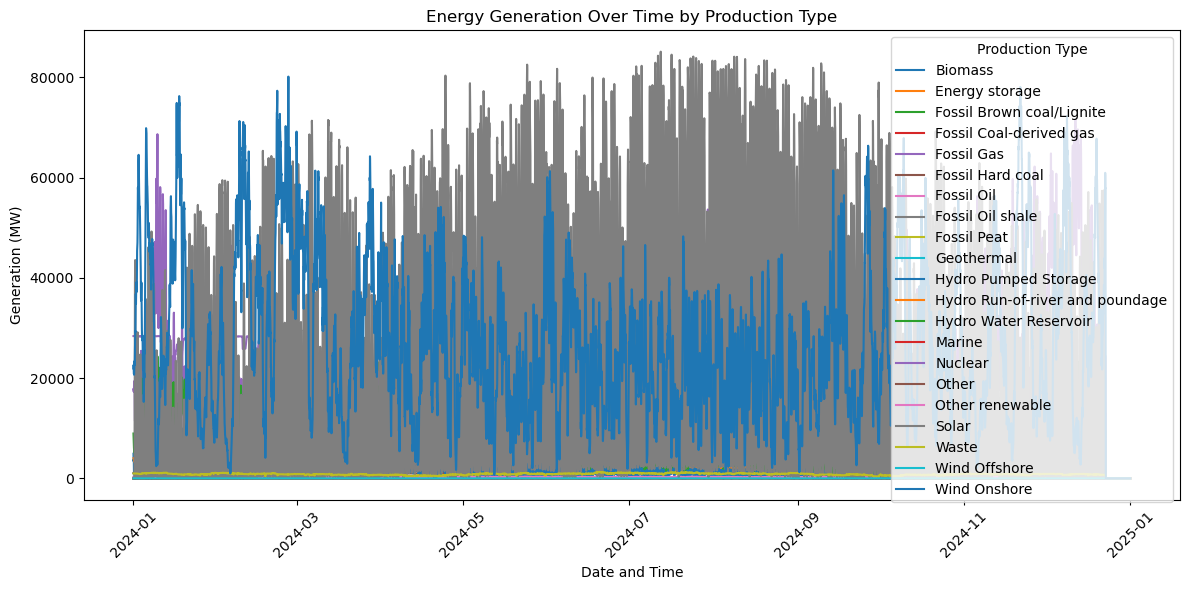

In [26]:
# Plotting the time-series for each production type
plt.figure(figsize=(12, 6))

# Iterate through each unique production type
for production_type in df_gen_hourly['Production Type'].unique():
    # Filter the data for the current production type
    production_data = df_gen_hourly[df_gen_hourly['Production Type'] == production_type]
    
    # Plot the generation data for the current production type
    plt.plot(production_data['DateTime'], production_data['Generation (MW)'], label=production_type)

# Adding labels and title
plt.xlabel('Date and Time')
plt.ylabel('Generation (MW)')
plt.title('Energy Generation Over Time by Production Type')
plt.legend(title='Production Type')

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45)

# Display the plot
plt.tight_layout()
plt.show()